# Introduction to Machine Learning with PyTorch
## Project: Finding Donors for *CharityML*

Welcome to the first project of the Data Scientist Nanodegree! In this notebook, some template code has already been provided for you, and it will be your job to implement the additional functionality necessary to successfully complete this project. Sections that begin with **'Implementation'** in the header indicate that the following block of code will require additional functionality which you must provide. Instructions will be provided for each section and the specifics of the implementation are marked in the code block with a `TODO` statement. Please be sure to read the instructions carefully!

In addition to implementing code, there will be questions that you must answer which relate to the project and your implementation. Each section where you will answer a question is preceded by a **'Question X'** header. Carefully read each question and provide thorough answers in the following text boxes that begin with **'Answer:'**. Your project submission will be evaluated based on your answers to each of the questions and the implementation you provide.  

>**Note:** Please specify **WHICH VERSION OF PYTHON** you are using when submitting this notebook. Code and Markdown cells can be executed using the **Shift + Enter** keyboard shortcut. In addition, Markdown cells can be edited by typically double-clicking the cell to enter edit mode.

## Getting Started

In this project, you will employ several supervised algorithms of your choice to accurately model individuals' income using data collected from the 1994 U.S. Census. You will then choose the best candidate algorithm from preliminary results and further optimize this algorithm to best model the data. Your goal with this implementation is to construct a model that accurately predicts whether an individual makes more than $50,000. This sort of task can arise in a non-profit setting, where organizations survive on donations.  Understanding an individual's income can help a non-profit better understand how large of a donation to request, or whether or not they should reach out to begin with.  While it can be difficult to determine an individual's general income bracket directly from public sources, we can (as we will see) infer this value from other publically available features. 

The dataset for this project originates from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Census+Income). The datset was donated by Ron Kohavi and Barry Becker, after being published in the article _"Scaling Up the Accuracy of Naive-Bayes Classifiers: A Decision-Tree Hybrid"_. You can find the article by Ron Kohavi [online](https://www.aaai.org/Papers/KDD/1996/KDD96-033.pdf). The data we investigate here consists of small changes to the original dataset, such as removing the `fnlwgt` feature and records with missing or ill-formatted entries.

----
## Exploring the Data
Run the code cell below to load necessary Python libraries and load the census data. Note that the last column from this dataset, `income`, will be our target label (whether an individual makes more than, or at most, $50,000 annually). All other columns are features about each individual in the census database.

In [2]:
# Import libraries necessary for this project
import numpy as np
import pandas as pd
from time import time
from IPython.display import display # Allows the use of display() for DataFrames

# Import supplementary visualization code visuals.py
import visuals as vs

# Pretty display for notebooks
%matplotlib inline

# Load the Census dataset
data = pd.read_csv("census.csv")

# Success - Display the first record
display(data.head(n=10))

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K
5,37,Private,Masters,14.0,Married-civ-spouse,Exec-managerial,Wife,White,Female,0.0,0.0,40.0,United-States,<=50K
6,49,Private,9th,5.0,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0.0,0.0,16.0,Jamaica,<=50K
7,52,Self-emp-not-inc,HS-grad,9.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,45.0,United-States,>50K
8,31,Private,Masters,14.0,Never-married,Prof-specialty,Not-in-family,White,Female,14084.0,0.0,50.0,United-States,>50K
9,42,Private,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178.0,0.0,40.0,United-States,>50K


### Implementation: Data Exploration
A cursory investigation of the dataset will determine how many individuals fit into either group, and will tell us about the percentage of these individuals making more than \$50,000. In the code cell below, you will need to compute the following:
- The total number of records, `n_records`
- The number of individuals making more than \$50,000 annually, `n_greater_50k`.
- The number of individuals making at most \$50,000 annually, `n_at_most_50k`.
- The percentage of individuals making more than \$50,000 annually, `greater_percent`.

**HINT:** You may need to look at the table above to understand how the `income` entries are formatted. 

In [43]:
# TODO: Total number of records
n_records = data.shape[0]

# TODO: Number of records where individual's income is more than $50,000
n_greater_50k = len(data[data['income'] == '>50K'])

# TODO: Number of records where individual's income is at most $50,000
n_at_most_50k = len(data[data['income'] == '<=50K'])

# TODO: Percentage of individuals whose income is more than $50,000
greater_percent = (n_greater_50k / n_records) * 100 if n_records > 0 else 0


# Print the results
print("Total number of records: {}".format(n_records))
print("Individuals making more than $50,000: {}".format(n_greater_50k))
print("Individuals making at most $50,000: {}".format(n_at_most_50k))
print("Percentage of individuals making more than $50,000: {}%".format(greater_percent))

assert n_records == n_greater_50k + n_at_most_50k

Total number of records: 45222
Individuals making more than $50,000: 11208
Individuals making at most $50,000: 34014
Percentage of individuals making more than $50,000: 24.78439697492371%


In [44]:
assert n_records == n_greater_50k + n_at_most_50k

**Featureset Exploration**

* **age**: continuous. 
* **workclass**: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked. 
* **education**: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool. 
* **education-num**: continuous. 
* **marital-status**: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse. 
* **occupation**: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces. 
* **relationship**: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried. 
* **race**: Black, White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other. 
* **sex**: Female, Male. 
* **capital-gain**: continuous. 
* **capital-loss**: continuous. 
* **hours-per-week**: continuous. 
* **native-country**: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

----
## Preparing the Data
Before data can be used as input for machine learning algorithms, it often must be cleaned, formatted, and restructured — this is typically known as **preprocessing**. Fortunately, for this dataset, there are no invalid or missing entries we must deal with, however, there are some qualities about certain features that must be adjusted. This preprocessing can help tremendously with the outcome and predictive power of nearly all learning algorithms.

### Transforming Skewed Continuous Features
A dataset may sometimes contain at least one feature whose values tend to lie near a single number, but will also have a non-trivial number of vastly larger or smaller values than that single number.  Algorithms can be sensitive to such distributions of values and can underperform if the range is not properly normalized. With the census dataset two features fit this description: `capital-gain` and `capital-loss`. 

Run the code cell below to plot a histogram of these two features. Note the range of the values present and how they are distributed.

/home/isah-idris/Documents/GitHub/AI-Infrastructure/finding_donors_supervised_learning/starter/visuals.py:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


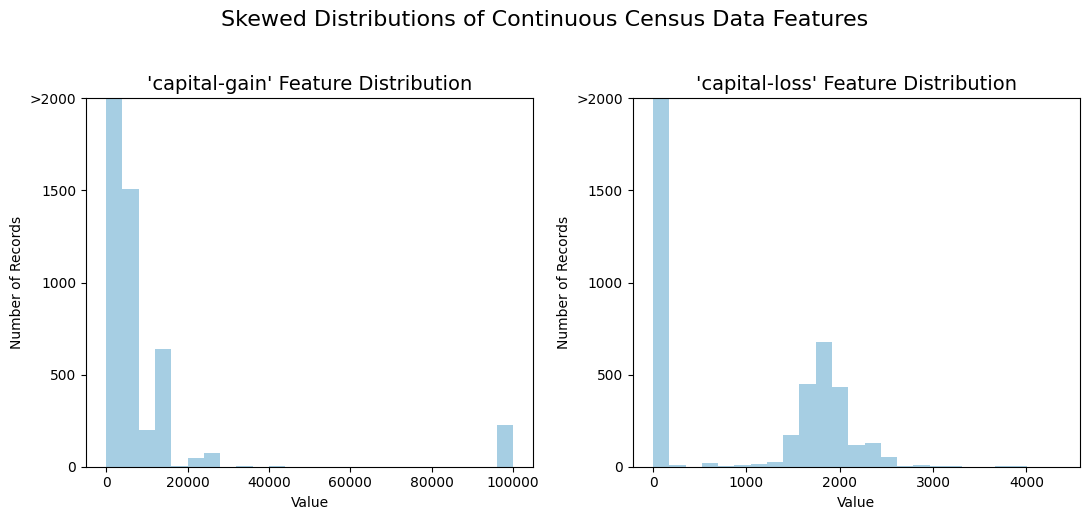

In [45]:
# Split the data into features and target label
income_raw = data['income']
features_raw = data.drop('income', axis = 1)

# Visualize skewed continuous features of original data
vs.distribution(data)

For highly-skewed feature distributions such as `capital-gain` and `capital-loss`, it is common practice to apply a [logarithmic transformation](https://en.wikipedia.org/wiki/Data_transformation_(statistics)) on the data so that the very large and very small values do not negatively affect the performance of a learning algorithm. Using a logarithmic transformation significantly reduces the range of values caused by outliers. Care must be taken when applying this transformation however: The logarithm of 0 is undefined, so we must translate the values by a small amount above 0 to apply the the logarithm successfully.

Run the code cell below to perform a transformation on the data and visualize the results. Again, note the range of values and how they are distributed. 

/home/isah-idris/Documents/GitHub/AI-Infrastructure/finding_donors_supervised_learning/starter/visuals.py:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


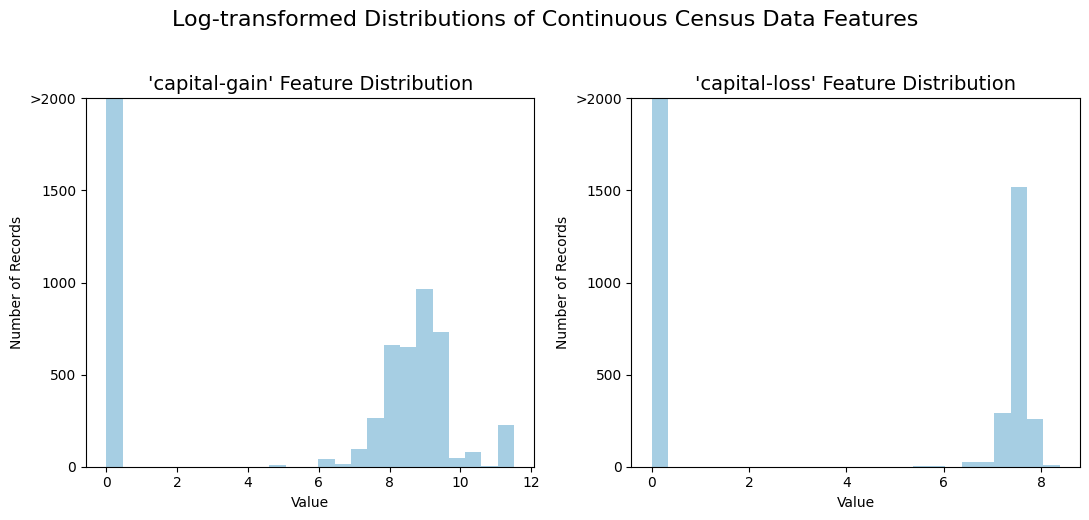

In [46]:
# Log-transform the skewed features
skewed = ['capital-gain', 'capital-loss']
features_log_transformed = pd.DataFrame(data = features_raw)
features_log_transformed[skewed] = features_raw[skewed].apply(lambda x: np.log(x + 1))

# Visualize the new log distributions
vs.distribution(features_log_transformed, transformed = True)

### Normalizing Numerical Features
In addition to performing transformations on features that are highly skewed, it is often good practice to perform some type of scaling on numerical features. Applying a scaling to the data does not change the shape of each feature's distribution (such as `capital-gain` or `capital-loss` above); however, normalization ensures that each feature is treated equally when applying supervised learners. Note that once scaling is applied, observing the data in its raw form will no longer have the same original meaning, as exampled below.

Run the code cell below to normalize each numerical feature. We will use [`sklearn.preprocessing.MinMaxScaler`](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) for this.

In [47]:
# Import sklearn.preprocessing.StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Initialize a scaler, then apply it to the features
scaler = MinMaxScaler() # default=(0, 1)
numerical = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

features_log_minmax_transform = pd.DataFrame(data = features_log_transformed)
features_log_minmax_transform[numerical] = scaler.fit_transform(features_log_transformed[numerical])

# Show an example of a record with scaling applied
display(features_log_minmax_transform.head(n = 5))

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,0.301370,State-gov,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.667492,0.0,0.397959,United-States
1,0.452055,Self-emp-not-inc,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0.0,0.122449,United-States
2,0.287671,Private,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.000000,0.0,0.397959,United-States
3,0.493151,Private,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.000000,0.0,0.397959,United-States
4,0.150685,Private,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.000000,0.0,0.397959,Cuba


### Implementation: Data Preprocessing

From the table in **Exploring the Data** above, we can see there are several features for each record that are non-numeric. Typically, learning algorithms expect input to be numeric, which requires that non-numeric features (called *categorical variables*) be converted. One popular way to convert categorical variables is by using the **one-hot encoding** scheme. One-hot encoding creates a _"dummy"_ variable for each possible category of each non-numeric feature. For example, assume `someFeature` has three possible entries: `A`, `B`, or `C`:

|   | someFeature |                    
| :-: | :-: |                            
| 0 |  B  |  
| 1 |  C  |
| 2 |  A  |  

We then encode this feature into `someFeature_A`, `someFeature_B` and `someFeature_C`:

|| someFeature_A | someFeature_B | someFeature_C |
| :-: | :-: | :-: | :-: |
|0| 0 | 1 | 0 |
|1| 0 | 0 | 1 |
|2| 1 | 0 | 0 |

Additionally, as with the non-numeric features, we need to convert the non-numeric target label, `income` to numerical values for the learning algorithm to work. Since there are only two possible categories for this label ("<=50K" and ">50K"), we can avoid using one-hot encoding and simply encode these two categories as 0 and 1, respectively. In code cell below, you will need to implement the following:
 - Use [`pandas.get_dummies()`](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.get_dummies.html?highlight=get_dummies#pandas.get_dummies) to perform one-hot encoding on the `features_log_minmax_transform` data.
 - Convert the target label `income_raw` to numerical entries.
   - Set records with "<=50K" to 0 and records with ">50K" to 1.

In [48]:
# TODO: One-hot encode the 'features_log_minmax_transform' data using pandas.get_dummies()
features_final = pd.get_dummies(features_log_minmax_transform)

# TODO: Encode the 'income_raw' data to numerical values
income = income_raw.apply(lambda x: 1 if x == '>50K' else 0)

# Print the number of features after one-hot encoding
encoded = list(features_final.columns)
print("{} total features after one-hot encoding.".format(len(encoded)))

# Uncomment the following line to see the encoded feature names
print(encoded)

103 total features after one-hot encoding.
['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass_ Federal-gov', 'workclass_ Local-gov', 'workclass_ Private', 'workclass_ Self-emp-inc', 'workclass_ Self-emp-not-inc', 'workclass_ State-gov', 'workclass_ Without-pay', 'education_level_ 10th', 'education_level_ 11th', 'education_level_ 12th', 'education_level_ 1st-4th', 'education_level_ 5th-6th', 'education_level_ 7th-8th', 'education_level_ 9th', 'education_level_ Assoc-acdm', 'education_level_ Assoc-voc', 'education_level_ Bachelors', 'education_level_ Doctorate', 'education_level_ HS-grad', 'education_level_ Masters', 'education_level_ Preschool', 'education_level_ Prof-school', 'education_level_ Some-college', 'marital-status_ Divorced', 'marital-status_ Married-AF-spouse', 'marital-status_ Married-civ-spouse', 'marital-status_ Married-spouse-absent', 'marital-status_ Never-married', 'marital-status_ Separated', 'marital-status_ Widowed', 'occupation_ A

### Shuffle and Split Data
Now all _categorical variables_ have been converted into numerical features, and all numerical features have been normalized. As always, we will now split the data (both features and their labels) into training and test sets. 80% of the data will be used for training and 20% for testing.

Run the code cell below to perform this split.

In [49]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split the 'features' and 'income' data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features_final, 
                                                    income, 
                                                    test_size = 0.2, 
                                                    random_state = 0)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

Training set has 36177 samples.
Testing set has 9045 samples.


----
## Evaluating Model Performance
In this section, we will investigate four different algorithms, and determine which is best at modeling the data. Three of these algorithms will be supervised learners of your choice, and the fourth algorithm is known as a *naive predictor*.

### Metrics and the Naive Predictor

*CharityML*, equipped with their research, knows individuals that make more than \$50,000 are most likely to donate to their charity. Because of this, *CharityML* is particularly interested in predicting who makes more than \$50,000 accurately. It would seem that using **accuracy** as a metric for evaluating a particular model's performace would be appropriate. Additionally, identifying someone that *does not* make more than \$50,000 as someone who does would be detrimental to *CharityML*, since they are looking to find individuals willing to donate. Therefore, a model's ability to precisely predict those that make more than \$50,000 is *more important* than the model's ability to **recall** those individuals. We can use **F-beta score** as a metric that considers both precision and recall:

$$ F_{\beta} = (1 + \beta^2) \cdot \frac{\text{precision} \cdot \text{recall}}{\left( \beta^2 \cdot \text{precision} \right) + \text{recall}} $$

In particular, when $\beta = 0.5$, more emphasis is placed on precision. This is called the $F_{0.5}$ score (or F-score for simplicity).

Looking at the distribution of classes (those who make at most \\$50,000, and those who make more), it's clear most individuals do not make more than \$50,000. This can greatly affect **accuracy**, since we could simply say *"this person does not make more than \$50,000"* and generally be right, without ever looking at the data! Making such a statement would be called **naive**, since we have not considered any information to substantiate the claim. It is always important to consider the *naive prediction* for your data, to help establish a benchmark for whether a model is performing well. That been said, using that prediction would be pointless: If we predicted all people made less than \$50,000, *CharityML* would identify no one as donors. 


#### Note: Recap of accuracy, precision, recall

**Accuracy** measures how often the classifier makes the correct prediction. It’s the ratio of the number of correct predictions to the total number of predictions (the number of test data points).

**Precision** tells us what proportion of messages we classified as spam, actually were spam.
It is a ratio of true positives (words classified as spam, and which are actually spam) to all positives (all words classified as spam, irrespective of whether that was the correct classificatio), in other words it is the ratio of

$$\text{Precision} = \frac{\text{True Positives}} {\text{True Positives} + \text{False Positives}}$$

**Recall (sensitivity)** tells us what proportion of messages that actually were spam were classified by us as spam.
It is a ratio of true positives (words classified as spam, and which are actually spam) to all the words that were actually spam, in other words it is the ratio of

$$\text{Recall} = \frac{\text{True Positives}} {\text{True Positives} + \text{False Negatives}}$$

For classification problems that are skewed in their classification distributions, like in our case, for example, if we had 100 text messages and only 2 were spam and the remaining 98 weren't, accuracy is not a very good metric. We could classify 90 messages as not spam (including the 2 that were spam, but we classify them as not spam, hence they would be false negatives) and 10 as spam (all 10 false positives) and still get a reasonably good accuracy score. For such cases, precision and recall come in very handy. These two metrics can be combined to get the F1 score and the weighted average (harmonic mean) of the precision and recall scores. This score can range from 0 to 1, with 1 being the best possible F1 score(we take the harmonic mean when dealing with ratios).

### Question 1 - Naive Predictor Performace
* If we chose a model that always predicted an individual made more than $50,000, what would  that model's accuracy and F-score be on this dataset? You must use the code cell below and assign your results to `accuracy` and `fscore` to be used later.

**Please note** that the the purpose of generating a naive predictor is simply to show what a base model without any intelligence would look like. In the real world, ideally your base model would be either the results of a previous model or could be based on a research paper upon which you are looking to improve. When there is no benchmark model set, getting a result better than random choice is a place you could start from.

**HINT:** 

* When we have a model that always predicts 1 (i.e., the individual makes more than 50k) then our model will have no True Negatives (TN) or False Negatives (FN) as we are not making any negative (0 value) predictions. Therefore our Accuracy in this case becomes the same as our Precision (True Positives / (True Positives + False Positives)) as every prediction that we have made with value 1 that should have 0 becomes a False Positive; therefore our denominator in this case is the total number of records we have in total. 
* Our Recall score (True Positives / (True Positives + False Negatives)) in this setting becomes 1 as we have no False Negatives.

In [71]:
TP = np.sum(income) # Counting the ones as this is the naive case. Note that 'income' is the 'income_raw' data encoded to numerical values done in the data preprocessing step.
FP = income.count() - TP # Specific to the naive case

TN = 0 # No predicted negatives in the naive case
FN = 0 # No predicted negatives in the naive case

# TODO: Calculate accuracy, precision and recall
accuracy = (TP + TN)/income.count() # this is same as TP/(TP+FP) or TP/(TP+FP+FN+TN)
recall = TP/(TP+FN)
precision = TP/(TP+FP)

# TODO: Calculate F-score using the formula above for beta = 0.5 and correct values for precision and recall.
fscore = (1 + 0.5**2) * (precision * recall)/((0.5**2 * precision) + recall)

# Print the results 
print("Naive Predictor: [Accuracy score: {:.4f}, F-score: {:.4f}]".format(accuracy, fscore))

Naive Predictor: [Accuracy score: 0.2478, F-score: 0.2917]


###  Supervised Learning Models
**The following are some of the supervised learning models that are currently available in** [scikit-learn](http://scikit-learn.org/stable/supervised_learning.html) **that you may choose from:**
- Gaussian Naive Bayes (GaussianNB)
- Decision Trees
- Ensemble Methods (Bagging, AdaBoost, Random Forest, Gradient Boosting)
- K-Nearest Neighbors (KNeighbors)
- Stochastic Gradient Descent Classifier (SGDC)
- Support Vector Machines (SVM)
- Logistic Regression

### Question 2 - Model Application
List three of the supervised learning models above that are appropriate for this problem that you will test on the census data. For each model chosen

- Describe one real-world application in industry where the model can be applied. 
- What are the strengths of the model; when does it perform well?
- What are the weaknesses of the model; when does it perform poorly?
- What makes this model a good candidate for the problem, given what you know about the data?

**HINT:**

Structure your answer in the same format as above^, with 4 parts for each of the three models you pick. Please include references with your answer.

**Answer:**

### Model Chosen
1. **Model 1: Logistic Regression**
2. **Model 2: Gradient Boosting**
3. **Model 3: Random Forest Classifier**

### Model 1: Logistic Regression
**Credit Risk Assessment in Financial Services:** Logistic regression is widely used to predict loan defaults. It helps lenders assess the likelihood of a borrower defaulting on a loan based on various features such as income, credit history, and employment status.

**Strengths**
- Inteparability: Provides clear probability estimates
- Efficiency: Fast to train even on large datasets; low computational cost
- Simplicity: Easy to implement
- Probabilistic Output: Provides probability estimates (0-1), useful for threshold tuning

**Weaknesses**
- Linearity Assumption: Assumes a linear relationship between features, thus cannot capture complex (non-linear) relationships
- Sensitive to Outliers: Outliers can significantly affect the model's performance
- Multicollinearity: Can be affected by highly correlated features, leading to unstable estimates
- Sensitive to feature scaling: Requires normalization of features for optimal performance
- Limited to binary classification: Cannot handle multi-class problems without modification

**Suitability for the Problem**

Logistic regression is a good candidate for this problem because it is a binary classification task (predicting whether an individual makes more than $50,000 or not). Additionally, logistic regression can provide probability estimates, which can be useful for understanding the confidence of predictions and for threshold tuning to optimize precision and recall. Given the dataset's size and the presence of both numerical and categorical features, logistic regression can efficiently handle the data after appropriate preprocessing (i.e., one-hot encoding for categorical variables and feature scaling for numerical variables).

**References**
- [An Application of Logistic Regression in Bank Lending Prediction: A Machine Learning Perspective](https://drpress.org/ojs/index.php/HBEM/article/view/27494)
- [Benchmarking state-of-the-art classification algorithms for credit scoring: An update of research](https://www.sciencedirect.com/science/article/abs/pii/S0377221715004208?via%3Dihub)
- [Machine learning for credit scoring: Improving logistic regression with non-linear decision-tree effects](https://www.sciencedirect.com/science/article/abs/pii/S0377221721005695)

### Model 2: Random Forest Classifier
**Loan Defaults, Customer Churn & Fraud Detection:** Random Forest is widely used in predicting loan defaults, customer churn, and fraud detection in e-commerce platforms.
It analyzes a wide of range of features such as credit history, income, and employment status, debt-to-income ratio, loan amount to assess risk. It can identify customers likely to churn by analyzing customer behavior, purchase history, and interactions with the company. While in fraud detection, It helps identify fraudulent transactions by analyzing patterns in transaction data, user behavior, and other relevant features.

**Strengths**
- Handles Mixed Data Types: Can effectively handle both numerical and categorical features, especially after one-hot encoding
- Robust to Overfitting: The ensemble approach of averaging or voting across multiple trees reduces the risk of overfitting compared to individual decision trees
- Feature Importance: Provides a built-in mechanism to evaluate the importance of each feature in making predictions, which can be useful for feature selection and understanding the data
- Handles Diverse Data: It is versatile and can be applied to a wide range of problems, including classification and regression tasks. It handles both numerical and categorical data effectively.
- Robust to Outliers: Less sensitive to outliers compared to linear models
- Parallelizable: Trees are built independently, thus can be trained in parallel across multiple CPU cores, which can speed up training on large datasets

**Weaknesses**
- Computational Complexity and Resource Intensive: Creating large numbers of trees requires significant computational power, memory, and storage, which can be slow, especially with large datasets
- Less Interpretable: The ensemble of hundreds or thousands of trees can make it difficult to interpret the model's decisions compared to simpler models like logistic regression or a single decision tree
- Slower Prediction Time: Making predictions can be slower than simpler models, especially if the number of trees is large which can be a concern for real-time applications
- Sensitive to Noisy Data: Can be sensitive to noisy data and outliers, which may lead to overfitting if not handled properly
- Bias in Imbalanced Datasets: Can struggle with imbalanced datasets, as it may be biased towards the majority class, leading to poor performance on the minority class

**Suitability for the Problem**

- Handles class imbalance with `class_weight` or by adjusting the decision threshold, which can help improve precision for the minority class (those making more than $50,000).
- Robust Performance: Generally achieves good performance on structured data.
- No strict feature scaling: Unlike logistic regression, random forest doesn't assume a linear relationship between features and the target variable, which may be present in the census data. Given the importance of precision in this problem, random forest's ability to model complex interactions can help improve the F-score.


**References**
- [Bank Customer Churn Prediction based on Random Forest Algorithm](https://dl.acm.org/doi/fullHtml/10.1145/3671151.3671331)
- [A study on predicting loan default based on the random forest algorithm](https://www.sciencedirect.com/science/article/pii/S1877050919320277)


### Model 3: Gradient Boosting (GradientBoostingClassifier or XGBoost, LightGBM)
**Customer Churn Prediction in Telecommunications:** Gradient boosting is commonly used to predict customer churn, which is the likelihood of a customer leaving a service. It helps companies identify at-risk customers based on features such as usage patterns, customer service interactions, and billing information.

**Strengths**
- High Predictive Power: Often achieves better performance than simpler models by combining multiple weak learners
- Handles Non-Linearity: Can capture complex relationships between features and the target variable
- Built-in Regularization: Parameters like Tree depth (max_depth), Shrinkage (learning_rate), number of trees (n_estimators), subsampling (sampling) reduce overfitting
- Robust to Outliers: Less sensitive to outliers compared to linear models
- Feature Importance: Provides insights into which features are most influential in predictions
- Flexibility: Can be used for both classification and regression tasks

**Weaknesses**
- Computationally Intensive: sequential training is slow to train, especially with large datasets and many trees
- Harder To Tune: Requires careful tuning of many parameters (e.g., learning_rate, max_depth, n_estimmators) to achieve optimal performance, which can be time-consuming
- Risk of Overfitting: If not properly regularized, it can overfit the training data, especially with a large number of trees
- Sensitive to Noisy Data: Can be sensitive to noisy data and outliers, which may lead to overfitting if not handled properly
- Less Interpretable: The ensemble of hundreds or thousands of trees can make it difficult to interpret the model's decisions compared to simpler models like logistic regression

**Suitability for the Problem**
- Excellent F-Score Performance: Known for achieving high F-scores in classification tasks, which is crucial for this problem where precision is more important than recall
- Handles Mixed Data Types: Can effectively handle both numerical and categorical features, especially after one-hot encoding
- Captures Complex Relationships: Can model complex interactions between features, which may be present in the census data


**References**
- [Explaining customer churn prediction in telecom industry using tabular machine learning models](https://www.sciencedirect.com/science/article/pii/S2666827024000434)
- [Gradient Boosting and Explainable AI for Financial Risk Management: A Comprehensive Review](https://www.preprints.org/manuscript/202504.0817#Conclusions)



### Implementation - Creating a Training and Predicting Pipeline
To properly evaluate the performance of each model you've chosen, it's important that you create a training and predicting pipeline that allows you to quickly and effectively train models using various sizes of training data and perform predictions on the testing data. Your implementation here will be used in the following section.
In the code block below, you will need to implement the following:
 - Import `fbeta_score` and `accuracy_score` from [`sklearn.metrics`](http://scikit-learn.org/stable/modules/classes.html#sklearn-metrics-metrics).
 - Fit the learner to the sampled training data and record the training time.
 - Perform predictions on the test data `X_test`, and also on the first 300 training points `X_train[:300]`.
   - Record the total prediction time.
 - Calculate the accuracy score for both the training subset and testing set.
 - Calculate the F-score for both the training subset and testing set.
   - Make sure that you set the `beta` parameter!

In [72]:
# TODO: Import two metrics from sklearn - fbeta_score and accuracy_score
from sklearn.metrics import accuracy_score, fbeta_score

def train_predict(learner, sample_size, X_train, y_train, X_test, y_test): 
    '''
    inputs:
       - learner: the learning algorithm to be trained and predicted on
       - sample_size: the size of samples (number) to be drawn from training set
       - X_train: features training set
       - y_train: income training set
       - X_test: features testing set
       - y_test: income testing set
    '''
    
    results = {}
    
    # TODO: Fit the learner to the training data using slicing with 'sample_size' using .fit(training_features[:], training_labels[:])
    start = time() # Get start time
    learner = learner.fit(X_train[:sample_size], y_train[:sample_size])
    end = time() # Get end time
    
    # TODO: Calculate the training time
    results['train_time'] = end - start
        
    # TODO: Get the predictions on the test set(X_test),
    #       then get predictions on the first 300 training samples(X_train) using .predict()
    start = time() # Get start time
    predictions_test = learner.predict(X_test)
    predictions_train = learner.predict(X_train[:300])
    end = time() # Get end time
    
    # TODO: Calculate the total prediction time
    results['pred_time'] = end - start
            
    # TODO: Compute accuracy on the first 300 training samples which is y_train[:300]
    results['acc_train'] = accuracy_score(y_train[:300], predictions_train)
        
    # TODO: Compute accuracy on test set using accuracy_score()
    results['acc_test'] = accuracy_score(y_test, predictions_test)
    
    # TODO: Compute F-score on the the first 300 training samples using fbeta_score()
    results['f_train'] = fbeta_score(y_train[:300], predictions_train, beta=0.5)
        
    # TODO: Compute F-score on the test set which is y_test
    results['f_test'] = fbeta_score(y_test, predictions_test, beta=0.5)
       
    # Success
    print("{} trained on {} samples.".format(learner.__class__.__name__, sample_size))
        
    # Return the results
    return results

### Implementation: Initial Model Evaluation
In the code cell, you will need to implement the following:
- Import the three supervised learning models you've discussed in the previous section.
- Initialize the three models and store them in `clf_A`, `clf_B`, and `clf_C`.
  - Use a `random_state` for each model you use, if provided.
  - **Note:** Use the default settings for each model — you will tune one specific model in a later section.
- Calculate the number of records equal to 1%, 10%, and 100% of the training data.
  - Store those values in `samples_1`, `samples_10`, and `samples_100` respectively.

**Note:** Depending on which algorithms you chose, the following implementation may take some time to run!

LogisticRegression trained on 361 samples.
LogisticRegression trained on 3617 samples.
LogisticRegression trained on 36177 samples.
RandomForestClassifier trained on 361 samples.
RandomForestClassifier trained on 3617 samples.
RandomForestClassifier trained on 36177 samples.
GradientBoostingClassifier trained on 361 samples.
GradientBoostingClassifier trained on 3617 samples.
GradientBoostingClassifier trained on 36177 samples.


/home/isah-idris/Documents/GitHub/AI-Infrastructure/finding_donors_supervised_learning/starter/visuals.py:122: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  pl.tight_layout()


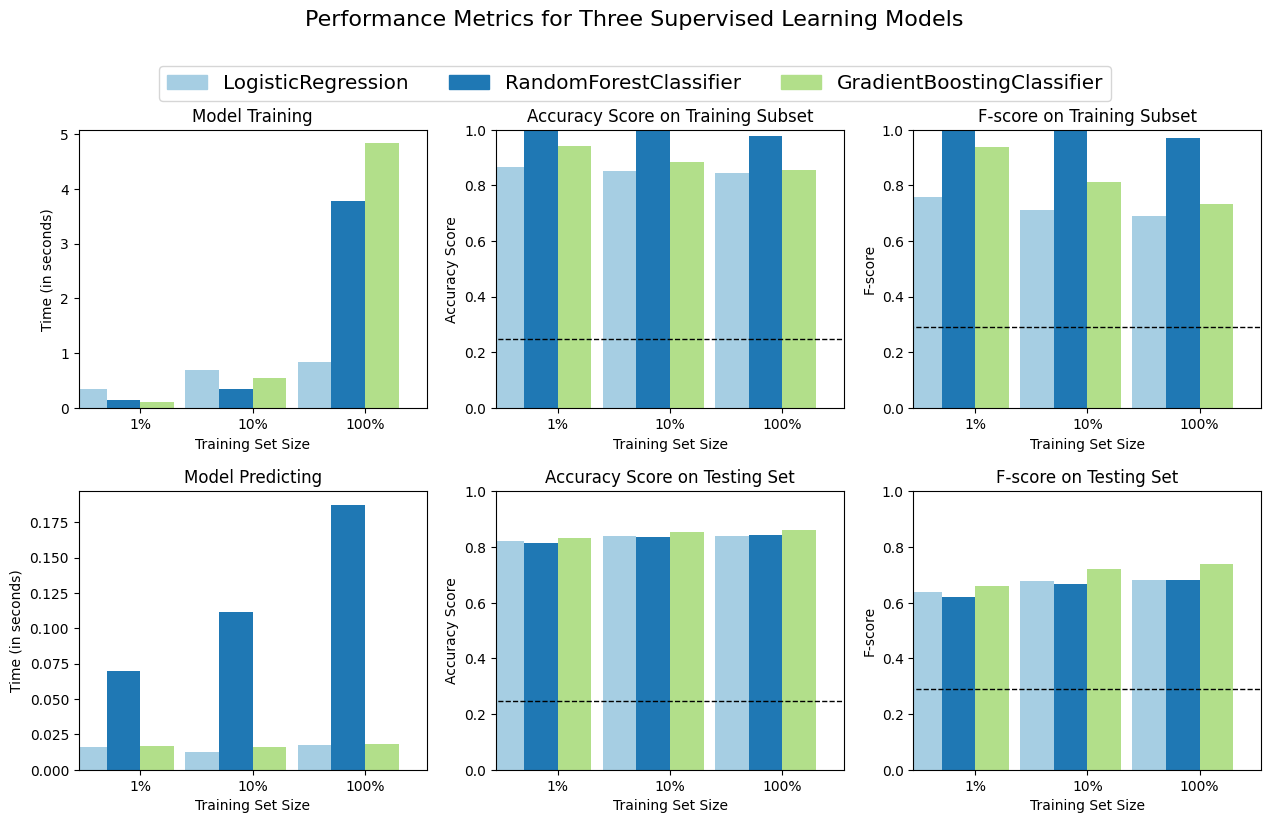

{'LogisticRegression': {0: {'train_time': 0.3405873775482178, 'pred_time': 0.016031265258789062, 'acc_train': 0.8666666666666667, 'acc_test': 0.8225538971807629, 'f_train': 0.7575757575757576, 'f_test': 0.6390457531404864}, 1: {'train_time': 0.6877765655517578, 'pred_time': 0.012429237365722656, 'acc_train': 0.85, 'acc_test': 0.8389165284687673, 'f_train': 0.7115384615384616, 'f_test': 0.6782505142362238}, 2: {'train_time': 0.8390724658966064, 'pred_time': 0.017458438873291016, 'acc_train': 0.8433333333333334, 'acc_test': 0.8416804864566059, 'f_train': 0.6902985074626866, 'f_test': 0.6825974025974026}}, 'RandomForestClassifier': {0: {'train_time': 0.1533658504486084, 'pred_time': 0.07011795043945312, 'acc_train': 1.0, 'acc_test': 0.8151464897733555, 'f_train': 1.0, 'f_test': 0.6201343713341154}, 1: {'train_time': 0.35068511962890625, 'pred_time': 0.11171412467956543, 'acc_train': 0.9966666666666667, 'acc_test': 0.8354892205638474, 'f_train': 0.9971910112359551, 'f_test': 0.668485675306

In [77]:
# TODO: Import the three supervised learning models from sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# TODO: Initialize the three models
clf_A = LogisticRegression(random_state=42)
clf_B = RandomForestClassifier(random_state=42)
clf_C = GradientBoostingClassifier(random_state=42)

# TODO: Calculate the number of samples for 1%, 10%, and 100% of the training data
# HINT: samples_100 is the entire training set i.e. len(y_train)
# HINT: samples_10 is 10% of samples_100 (ensure to set the count of the values to be `int` and not `float`)
# HINT: samples_1 is 1% of samples_100 (ensure to set the count of the values to be `int` and not `float`)
samples_100 = len(y_train)
samples_10 = int(samples_100 * 0.10)
samples_1 = int(samples_100 * 0.01)

# Collect results on the learners
results = {}
for clf in [clf_A, clf_B, clf_C]:
    clf_name = clf.__class__.__name__
    results[clf_name] = {}
    for i, samples in enumerate([samples_1, samples_10, samples_100]):
        results[clf_name][i] = \
        train_predict(clf, samples, X_train, y_train, X_test, y_test)

# Run metrics visualization for the three supervised learning models chosen
vs.evaluate(results, accuracy, fscore)
print(results)

----
## Improving Results
In this final section, you will choose from the three supervised learning models the *best* model to use on the student data. You will then perform a grid search optimization for the model over the entire training set (`X_train` and `y_train`) by tuning at least one parameter to improve upon the untuned model's F-score. 

### Question 3 - Choosing the Best Model

* Based on the evaluation you performed earlier, in one to two paragraphs, explain to *CharityML* which of the three models you believe to be most appropriate for the task of identifying individuals that make more than $50,000. 

**HINT:** 
Look at the graph at the bottom left from the cell above(the visualization created by `vs.evaluate(results, accuracy, fscore)`) and check the F score for the testing set when 100% of the training set is used. Which model has the highest score? Your answer should include discussion of the:
* metrics - F score on the testing when 100% of the training data is used, 
* prediction/training time
* the algorithm's suitability for the data.

**Answer:**

**Recommendation: Gradient Boosting Classifier**

**Metrics**

Based on the evaluation metrics at 100% training data, the Gradient Boosting Classifier is the most appropriate model for CharityML's goal of identifying potential donors earning more than $50,000. 
It achieved the highest F-score on the test set of 0.7395 and the highest test accuracy of 0.8630, outperforming both Logistic Regression (F-score: 0.6826) and Random Forest (F-score: 0.6813). 
Critically, the F-score is the most relevant metric here because CharityML needs a balance between precision (correctly identifying true donors) and recall (not missing potential donors) — and the beta=0.5 weighting means the model is appropriately penalized more for false positives, which would waste CharityML's outreach resources. Furthermore, unlike Random Forest which showed a severe train/test gap (0.9706 vs 0.6813), Gradient Boosting's train and test scores converged closely (0.7341 vs 0.7395), demonstrating genuine generalization rather than memorization of training data.

**Prediction/Training Time**

Regarding computational cost, the Gradient Boosting Classifier does require the longest training time at 4.247 seconds on the full dataset. However, this is an acceptable trade-off for CharityML because model training is a one-time cost — once trained, predictions are fast (0.016s), which is what matters at deployment when screening thousands of individuals. 

**Algorithm Suitability**

The algorithm is particularly well-suited to this dataset because census income prediction involves complex non-linear relationships between features like education level, occupation, hours worked, and capital gains — patterns that Gradient Boosting's sequential tree-building process is specifically designed to capture. Logistic Regression's performance plateau confirmed that a linear decision boundary is insufficient for this problem, while Gradient Boosting's consistent F-score improvement from 0.659 → 0.722 → 0.740 across increasing sample sizes indicates it will continue to benefit from more donor data as CharityML grows its dataset.

### Question 4 - Describing the Model in Layman's Terms

* In one to two paragraphs, explain to *CharityML*, in layman's terms, how the final model chosen is supposed to work. Be sure that you are describing the major qualities of the model, such as how the model is trained and how the model makes a prediction. Avoid using advanced mathematical jargon, such as describing equations.

**HINT:**

When explaining your model, if using external resources please include all citations.

**Answer:** 

**How Gradient Boosting Works in Layman's Terms**

Imagine CharityML hires a team of junior analysts to review census records and predict who earns above $50,000. The first analyst reviews the records and makes predictions, but gets several individuals wrong. Rather than starting over, the team takes note of exactly who was predicted incorrectly and brings in a second analyst whose only job is to focus on those difficult cases. A third analyst then steps in to handle what the second analyst still got wrong. This process repeats many times — each new analyst is specifically brought in to fix the mistakes the previous analysts made. At the end, all analysts put their conclusions together into one final group decision, much like a panel of judges reaching a verdict.

**How the Model Makes a Prediction**

When a new individual's census information comes in — their age, education, occupation, hours worked — it is passed through every analyst on the panel, one by one. Each analyst looks at the information and gives an answer: "likely donor" or "unlikely donor". Analysts who consistently proved themselves more reliable during training get more say in the final answer — think of it like a courtroom where a senior judge's opinion counts more than a junior one. The panel's combined answer is the model's final prediction for CharityML — either this person is worth reaching out to, or they are not.

### Implementation: Model Tuning
Fine tune the chosen model. Use grid search (`GridSearchCV`) with at least one important parameter tuned with at least 3 different values. You will need to use the entire training set for this. In the code cell below, you will need to implement the following:
- Import [`sklearn.grid_search.GridSearchCV`](http://scikit-learn.org/0.17/modules/generated/sklearn.grid_search.GridSearchCV.html) and [`sklearn.metrics.make_scorer`](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html).
- Initialize the classifier you've chosen and store it in `clf`.
 - Set a `random_state` if one is available to the same state you set before.
- Create a dictionary of parameters you wish to tune for the chosen model.
 - Example: `parameters = {'parameter' : [list of values]}`.
 - **Note:** Avoid tuning the `max_features` parameter of your learner if that parameter is available!
- Use `make_scorer` to create an `fbeta_score` scoring object (with $\beta = 0.5$).
- Perform grid search on the classifier `clf` using the `scorer`, and store it in `grid_obj`.
- Fit the grid search object to the training data (`X_train`, `y_train`), and store it in `grid_fit`.

**Note:** Depending on the algorithm chosen and the parameter list, the following implementation may take some time to run!

In [84]:
# TODO: Import 'GridSearchCV', 'make_scorer', and any other necessary libraries
from sklearn.model_selection import GridSearchCV 
from sklearn.metrics import make_scorer


# TODO: Initialize the classifier
clf = GradientBoostingClassifier(
    n_estimators=500,               
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    n_iter_no_change=10,            # stop if no improvement after trees
    validation_fraction=0.1         # use 10% of trainging data to monitor
)

#clf.fit(X_train, y_train)
#print(f"Optimal Estimators: {clf.n_estimators_}") find the optimal number of trees required

# TODO: Create the parameters list you wish to tune, using a dictionary if needed.
# HINT: parameters = {'parameter_1': [value1, value2], 'parameter_2': [value1, value2]}
parameters = {
    'n_estimators': [100, 200, 392],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

# TODO: Make an fbeta_score scoring object using make_scorer()
scorer = make_scorer(fbeta_score, beta=0.5)

# TODO: Perform grid search on the classifier using 'scorer' as the scoring method using GridSearchCV()
grid_obj = GridSearchCV(clf, parameters, scoring=scorer, cv=5)

# TODO: Fit the grid search object to the training data and find the optimal parameters using fit()
grid_fit = grid_obj.fit(X_train, y_train)

# Get the estimator
best_clf = grid_fit.best_estimator_

# Make predictions using the unoptimized and model
predictions = (clf.fit(X_train, y_train)).predict(X_test)
best_predictions = best_clf.predict(X_test)

# Report the before-and-afterscores
print("Unoptimized model\n------")
print("Accuracy score on testing data: {:.4f}".format(accuracy_score(y_test, predictions)))
print("F-score on testing data: {:.4f}".format(fbeta_score(y_test, predictions, beta = 0.5)))
print("\nOptimized Model\n------")
print("Final accuracy score on the testing data: {:.4f}".format(accuracy_score(y_test, best_predictions)))
print("Final F-score on the testing data: {:.4f}".format(fbeta_score(y_test, best_predictions, beta = 0.5)))

Unoptimized model
------
Accuracy score on testing data: 0.8699
F-score on testing data: 0.7508

Optimized Model
------
Final accuracy score on the testing data: 0.8710
Final F-score on the testing data: 0.7519


### Question 5 - Final Model Evaluation

* What is your optimized model's accuracy and F-score on the testing data? 
* Are these scores better or worse than the unoptimized model? 
* How do the results from your optimized model compare to the naive predictor benchmarks you found earlier in **Question 1**?  

**Note:** Fill in the table below with your results, and then provide discussion in the **Answer** box.

#### Results:

|     Metric     | Unoptimized Model | Optimized Model |
| :------------: | :---------------: | :-------------: | 
| Accuracy Score |   0.8699          |   0.8710        |
| F-score        |   0.7508          |   0.7519        |


**Answer:**
- The optimized model's accuracy on the testing data is 0.8710, and its F-score is 0.7519.
- These scores are slightly better than the unoptimized model, which had an accuracy of 0.8699 and an F-score of 0.7508. The improvement is marginal, indicating that the default parameters were already close to optimal for this dataset, but the tuning process still provided a small boost in performance.
- Compared to the naive predictor benchmarks from Question 1, which had an accuracy of 0.2478 and an F-score of 0.2917, the optimized model performs significantly better. The optimized model's accuracy and F-score are more than three times higher than the naive predictor, demonstrating that the model has successfully learned to identify individuals who make more than $50,000 with a much higher degree of precision.

----
## Feature Importance

An important task when performing supervised learning on a dataset like the census data we study here is determining which features provide the most predictive power. By focusing on the relationship between only a few crucial features and the target label we simplify our understanding of the phenomenon, which is most always a useful thing to do. In the case of this project, that means we wish to identify a small number of features that most strongly predict whether an individual makes at most or more than $50,000.

Choose a scikit-learn classifier (e.g., adaboost, random forests) that has a `feature_importance_` attribute, which is a function that ranks the importance of features according to the chosen classifier.  In the next python cell fit this classifier to training set and use this attribute to determine the top 5 most important features for the census dataset.

### Question 6 - Feature Relevance Observation
When **Exploring the Data**, it was shown there are thirteen available features for each individual on record in the census data. Of these thirteen records, which five features do you believe to be most important for prediction, and in what order would you rank them and why?

**Answer:**

1. **Capital-gain**: Large capital gains are almost exclusively associated with high-income individuals, making this feature a strong predictor of earning more than $50,000.
2. **Education-level**: Higher education levels typically correlate with higher-paying jobs, so this feature is likely to be a significant predictor of income level.
3. **Occupation**: Professional and managerial roles have structurally higher earning potential, making this feature a strong predictor of income level.
4. **Age**: Income generally increases with age up to a certain point, as individuals gain experience and advance in their careers, making this feature relevant for predicting income level.
5. **Hours-per-week**: Individuals working more hours per week may have higher income, especially if they are in high-paying jobs that require long hours, making this feature a useful predictor of income level.

### Implementation - Extracting Feature Importance
Choose a `scikit-learn` supervised learning algorithm that has a `feature_importance_` attribute availble for it. This attribute is a function that ranks the importance of each feature when making predictions based on the chosen algorithm.

In the code cell below, you will need to implement the following:
 - Import a supervised learning model from sklearn if it is different from the three used earlier.
 - Train the supervised model on the entire training set.
 - Extract the feature importances using `.feature_importances_`.

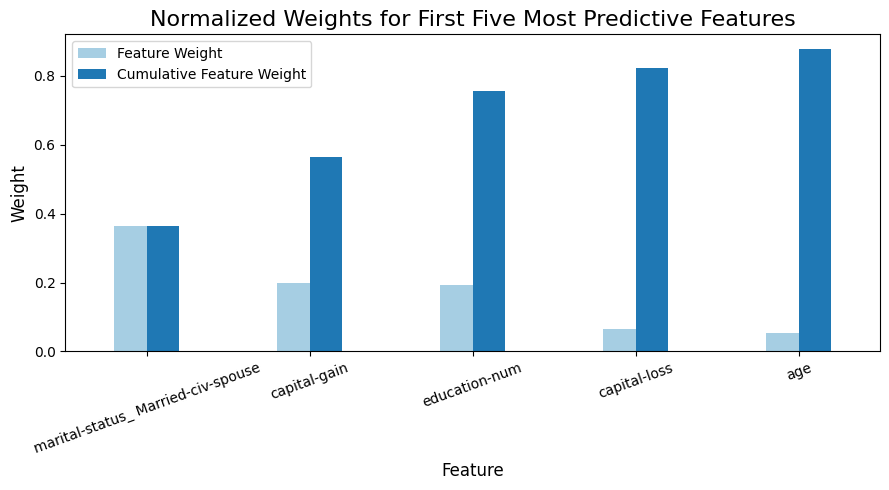

In [85]:
# TODO: Import a supervised learning model that has 'feature_importances_'
# GradientBoostClassifier already has feature_importances_ built-in

# TODO: Train the supervised model on the training set using .fit(X_train, y_train)
model = best_clf

# TODO: Extract the feature importances using .feature_importances_ 
importances = model.feature_importances_

# Plot
vs.feature_plot(importances, X_train, y_train)

### Question 7 - Extracting Feature Importance

Observe the visualization created above which displays the five most relevant features for predicting if an individual makes at most or above $50,000.  
* How do these five features compare to the five features you discussed in **Question 6**?
* If you were close to the same answer, how does this visualization confirm your thoughts? 
* If you were not close, why do you think these features are more relevant?

**Answer:**

- The five features identified as most important by the model are `capital-gain`, `capital-loss`,`education-num`, `age`, and `marital-status`. Only two features `capital-gain` and `age` closely align with the ones I discussed in Question 6.
- The visualization confirms my thoughts on the importance of `capital-gain` and `age` as strong predictors of income level, as they are ranked as the top two features in the model's feature importance. 
- The model's identification of `capital-loss`, `education-num`, and `marital-status` as more relevant than `education-level`, `occupation`, and `hours-per-week` suggests that the model found stronger predictive patterns in these features based on the data.

>***Note***:
I discussed `Education-level` as oppose to `education-num` since years of education is not a direct measure of educational achievement - The credential itself is what employers use to determine salary potential. Furthermore,`Occupation` and `Hours-per-week` are more indication of high earning than `marital-status`. And of course, low `capital-gain` covers for `capital-loss`.

### Feature Selection
How does a model perform if we only use a subset of all the available features in the data? With less features required to train, the expectation is that training and prediction time is much lower — at the cost of performance metrics. From the visualization above, we see that the top five most important features contribute more than half of the importance of **all** features present in the data. This hints that we can attempt to *reduce the feature space* and simplify the information required for the model to learn. The code cell below will use the same optimized model you found earlier, and train it on the same training set *with only the top five important features*. 

In [86]:
# Import functionality for cloning a model
from sklearn.base import clone

# Reduce the feature space
X_train_reduced = X_train[X_train.columns.values[(np.argsort(importances)[::-1])[:5]]]
X_test_reduced = X_test[X_test.columns.values[(np.argsort(importances)[::-1])[:5]]]

# Train on the "best" model found from grid search earlier
clf = (clone(best_clf)).fit(X_train_reduced, y_train)

# Make new predictions
reduced_predictions = clf.predict(X_test_reduced)

# Report scores from the final model using both versions of data
print("Final Model trained on full data\n------")
print("Accuracy on testing data: {:.4f}".format(accuracy_score(y_test, best_predictions)))
print("F-score on testing data: {:.4f}".format(fbeta_score(y_test, best_predictions, beta = 0.5)))
print("\nFinal Model trained on reduced data\n------")
print("Accuracy on testing data: {:.4f}".format(accuracy_score(y_test, reduced_predictions)))
print("F-score on testing data: {:.4f}".format(fbeta_score(y_test, reduced_predictions, beta = 0.5)))

Final Model trained on full data
------
Accuracy on testing data: 0.8710
F-score on testing data: 0.7519

Final Model trained on reduced data
------
Accuracy on testing data: 0.8579
F-score on testing data: 0.7239


### Question 8 - Effects of Feature Selection

* How does the final model's F-score and accuracy score on the reduced data using only five features compare to those same scores when all features are used?
* If training time was a factor, would you consider using the reduced data as your training set?

**Answer:**
- The final model's F-score and accuracy score on the reduced data are 0.7239 and 0.8579, respectively. Slightly  lower than the scores when all features were used (F-score: 0.7519, Accuracy: 0.8710), but still reasonably close, indicating that the top five features capture most of the predictive power of the full feature set.
- The reduced feature set at `3.9s` as opposed to `17m 13.8s` for the full feature set. If training time was a factor, I would consider using the reduced data as the training set, especially if the decrease in performance metrics is acceptable for the application's needs. The reduced feature set achieved a good balance between model performance and computational efficiency, making it a viable option for scenarios where quick predictions are necessary or computational resources are limited. 

> **Note**: Once you have completed all of the code implementations and successfully answered each question above, you may finalize your work by exporting the iPython Notebook as an HTML document. You can do this by using the menu above and navigating to  
**File -> Download as -> HTML (.html)**. Include the finished document along with this notebook as your submission.